In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os 
!pip install ultralytics

In [2]:
dataset_path = '/kaggle/input/datasets/norbertelter/pcb-defect-dataset'  # adjust if needed

# Walk the directory to understand the structure
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:  # only show files 2 levels deep
        subindent = ' ' * 2 * (level + 1)
        for file in files[:5]:  # first 5 files only
            print(f'{subindent}{file}')

pcb-defect-dataset/
  pcb-defect-dataset/
    data.yaml
    val/
      labels/
      images/
    test/
      labels/
      images/
    train/
      labels/
      images/


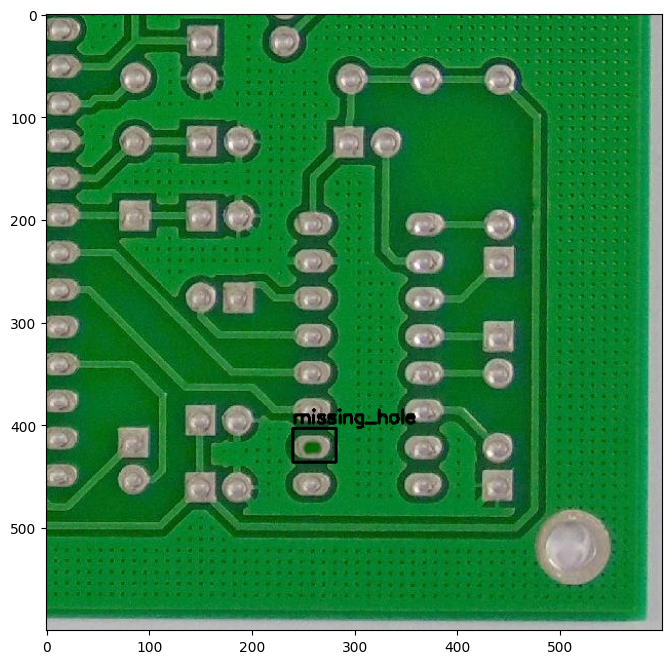

In [3]:
def visualize_yolo_annotation(img_path, label_path, class_names):
    img = cv2.imread(img_path) 
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 
    h,w = img.shape[0:2] 
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f.readlines():
                cls, cx, cy, bw, bh = map(float, line.strip().split())
                x1 = int((cx - bw/2) * w)
                y1 = int((cy - bh/2)* h)
                x2 = int((cx + bw/2) * w)
                y2 = int((cy + bh/2)* h)

                label = class_names[int(cls)] 

                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 0), 2)
                cv2.putText(img,label, (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, .6, (0, 0, 0) , 2)
        

    return img 



sample_img = '/kaggle/input/datasets/norbertelter/pcb-defect-dataset/pcb-defect-dataset/train/images/l_light_01_missing_hole_01_1_600.jpg'
sample_label = '/kaggle/input/datasets/norbertelter/pcb-defect-dataset/pcb-defect-dataset/train/labels/l_light_01_missing_hole_01_1_600.txt'

class_names = ['mouse_bite', 'spur', 'missing_hole', 'short', 'open_circuit', 'spurious_copper']

annotated = visualize_yolo_annotation(sample_img, sample_label, class_names) 

plt.figure(figsize=(12, 8))
plt.imshow(annotated)




In [4]:
yaml_content = """
path: /kaggle/input/datasets/norbertelter/pcb-defect-dataset/pcb-defect-dataset
train: train/images
val: val/images
test: test/images
names:
  0: mouse_bite
  1: spur
  2: missing_hole
  3: short
  4: open_circuit
  5: spurious_copper
"""
with open("pcb.yaml", "w") as f:
    f.write(yaml_content)
print('config created')

config created


In [5]:
# Start training
from ultralytics import YOLO

model = YOLO('yolov8n.pt')  # start from pretrained nano model

results = model.train(
    data='pcb.yaml',
    epochs=30,
    imgsz=640,
    batch=16,
    name='pcb_defect_v1',
    device='cuda',
    patience=10,        # early stopping
    save=True,
    plots=True          # saves training curves automatically
)

Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=pcb.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=pcb_defect_v1-8, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspecti

In [12]:
#check results 

print(f"Best mAP@50: {results.results_dict['metrics/mAP50(B)']:.3f}")

Best mAP@50: 0.989


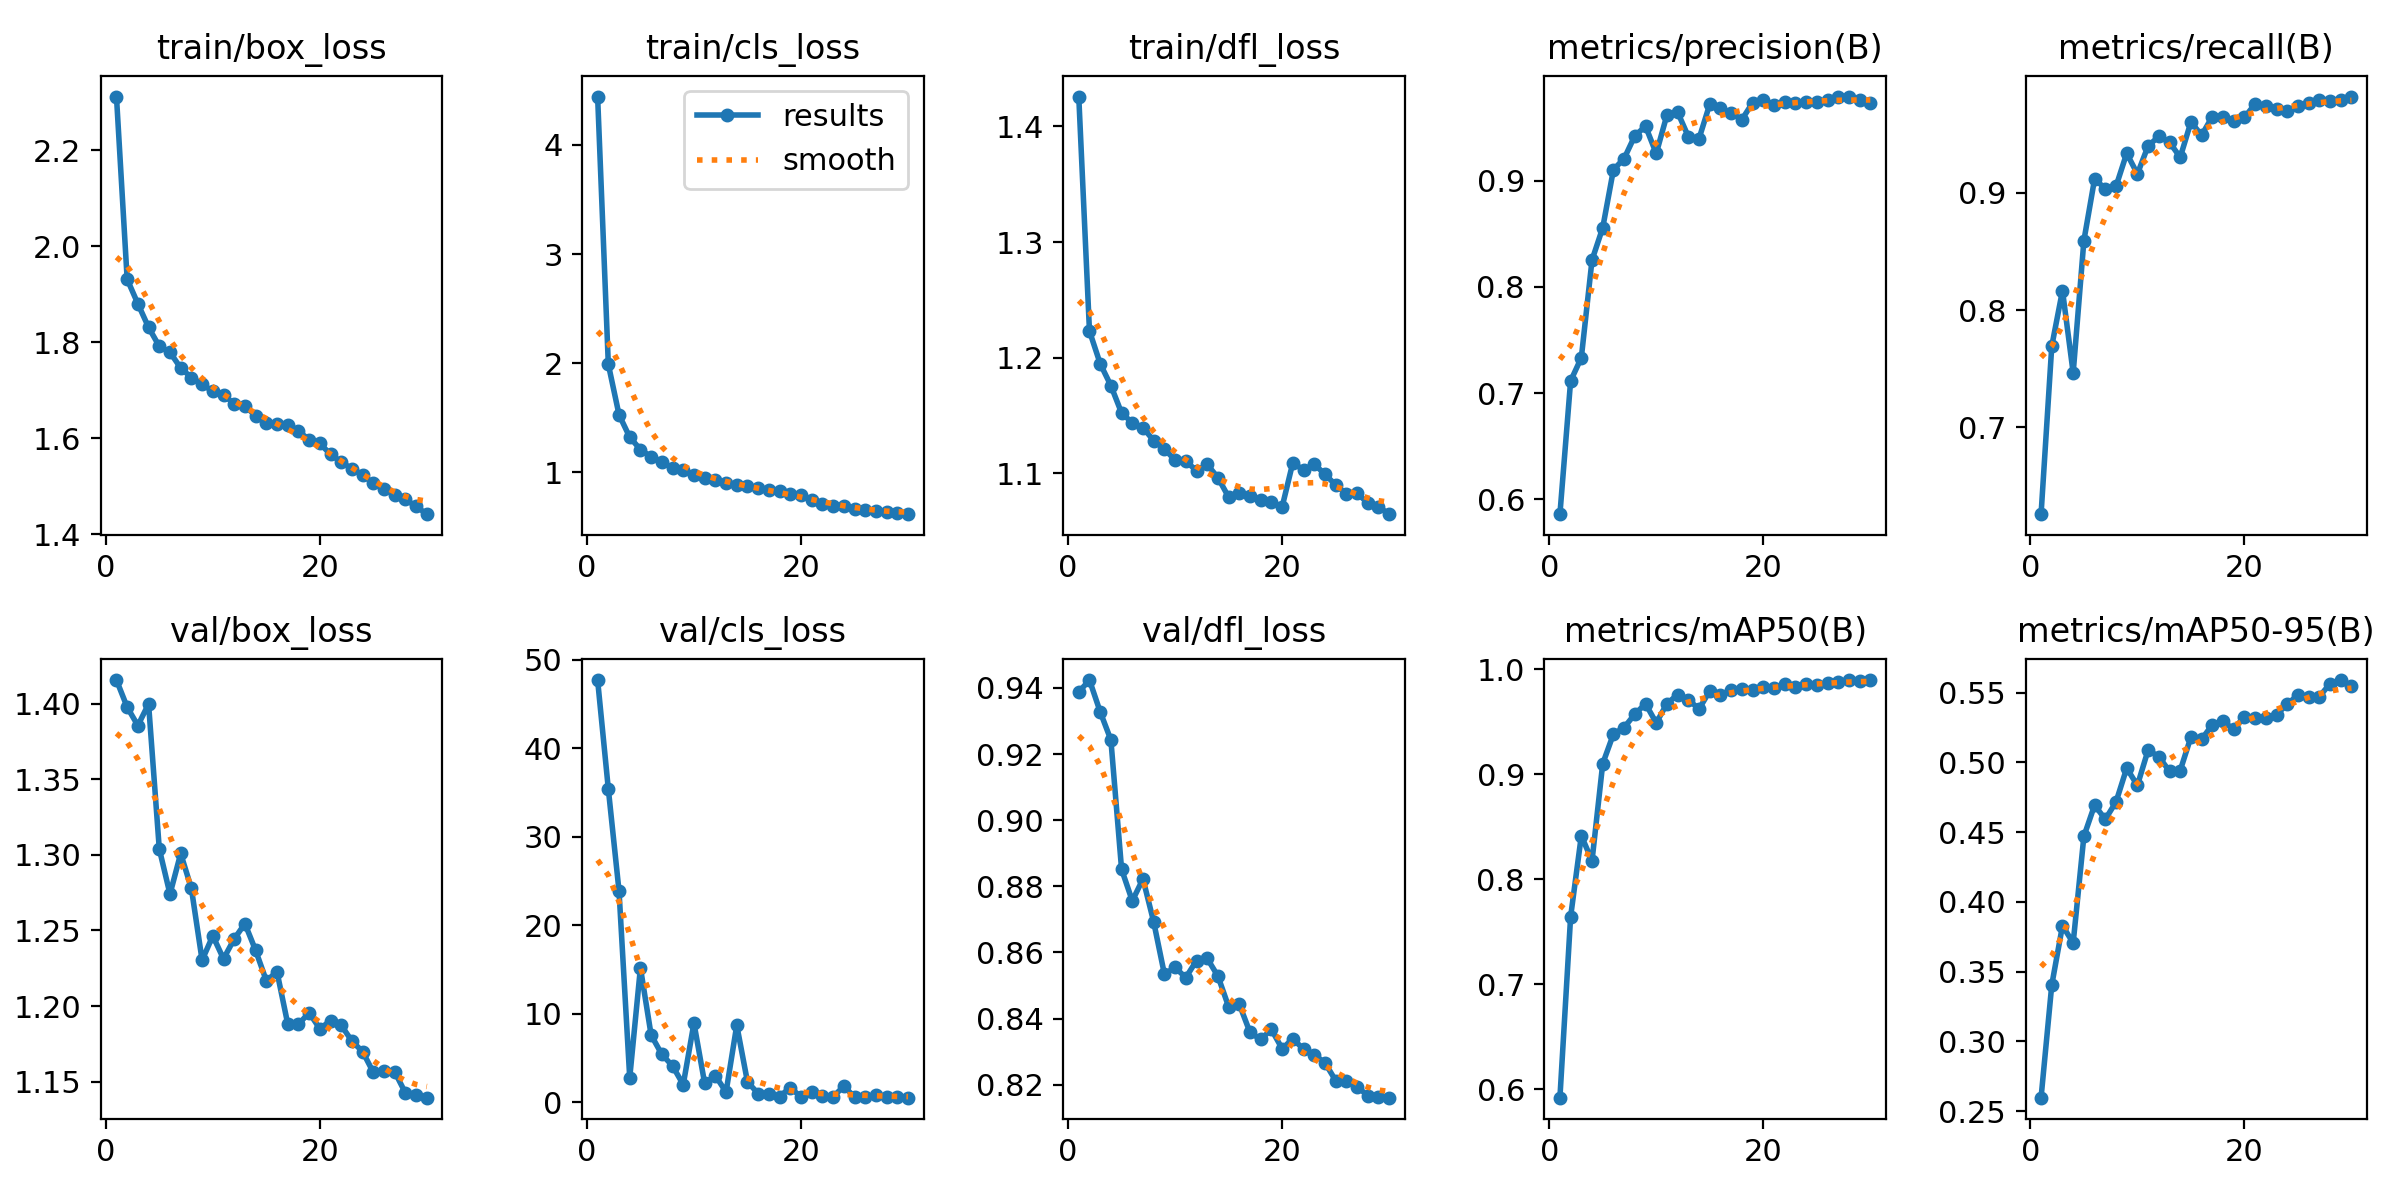

In [15]:
# Look at the training plots 

from IPython.display import Image as IPImage 
IPImage('/kaggle/working/runs/detect/pcb_defect_v1-8/results.png')


# Model Training Insights & Validation

I just finished training a YOLOv8n model on the PCB defect dataset for 30 epochs, and the results are looking incredibly strong. Here is a quick breakdown of how the run went, what the numbers actually mean, and a quick sanity check to keep in mind.

---

##  Performance Breakdown

* **mAP@50 hit a peak of 0.989.** At a standard 0.50 IoU threshold, the model is practically flawless at locating and identifying defects. 
* **mAP@50-95 stabilized around 0.55.** This is a perfectly healthy gap. It tells us that while the model is brilliant at finding and classifying the anomalies, it isn't "magically" pixel-perfect with its bounding box tight lines—which is exactly what we expect from a fast, lightweight nano model.
* **Precision and Recall both crossed 0.95 cleanly.** False alarms and missed defects are remarkably low.

---

##  Loss & Learning Behavior

* **Clean Convergence:** Both the training and validation losses (`box`, `cls`, and `dfl`) dropped smoothly over the 30 epochs. 
* **Zero Overfitting Signs:** The validation curves track the training curves beautifully right until the end. There are no sudden upward spikes in validation loss, meaning early stopping (`patience=10`) didn't even need to step in—the training length was spot on.

---

## Is 0.989 too good to be true?

In typical computer vision tasks, hitting a ~99% metric immediately screams overfitting or data leakage. However, for an automated industrial inspection setup like PCBs, this is actually quite realistic because:
1. **The environment is highly controlled:** The lighting, background, camera distance, and board geometry are completely static and predictable.
2. **Defects break the pattern:** Things like a `missing_hole` or a `short` create high-contrast structural anomalies that stick out clearly to a neural network.

**Next Step to be 100% sure:** I just need to verify our dataset split strategy. As long as images from the *exact same physical board* aren't accidentally split across both the training and validation sets, this near-perfect score is completely legitimate and ready for real-world testing.

### Invistigation 

Train_distribution
  mouse_bite: 2980
  spur: 2919
  missing_hole: 2902
  short: 2731
  open_circuit: 2844
  spurious_copper: 2966


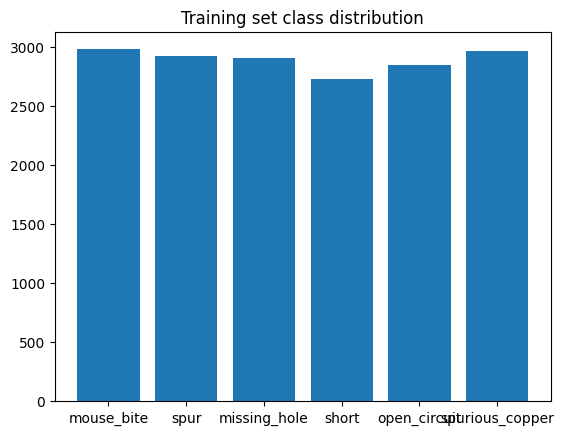

In [4]:
# Check class imbalance 
import os 
from collections import Counter 
import matplotlib.pyplot as plt 

def class_distribution(label_dir):
    class_counts = Counter() 
    for file in os.listdir(label_dir):
        if not file.endswith('txt'):
            continue 
        with open(os.path.join(label_dir, file)) as f:
            for line in f:
                cls_id = int(line.split()[0])
                class_counts[cls_id] += 1 
    return class_counts 


train_counts = class_distribution('/kaggle/input/datasets/norbertelter/pcb-defect-dataset/pcb-defect-dataset/train/labels')
val_counts = class_distribution('/kaggle/input/datasets/norbertelter/pcb-defect-dataset/pcb-defect-dataset/val/labels')
        
class_names = ['mouse_bite', 'spur', 'missing_hole', 'short', 'open_circuit', 'spurious_copper']

print("Train_distribution")
for i, name in enumerate(class_names):
    print(f'  {name}: {train_counts.get(i, 0)}') 

plt.bar(class_names, [train_counts.get(i,0) for i in range(6)]) 
plt.title('Training set class distribution')
plt.show()

That class distribution is clean and balanced!

In [11]:
# Train/Val leakage check 

import hashlib 

def hash_img(path):
    with open (path, 'rb') as file:
        hashed = hashlib.md5(file.read())
        return hashed.hexdigest() # return it as a str.


train_hashes = {} 
val_hashes = {}

train_dir = '/kaggle/input/datasets/norbertelter/pcb-defect-dataset/pcb-defect-dataset/train/images'
val_dir =  '/kaggle/input/datasets/norbertelter/pcb-defect-dataset/pcb-defect-dataset/val/images'
for file in os.listdir(train_dir):
    img = os.path.join(train_dir, file)
    h = hash_img(img) 
    train_hashes[h] = img # hash is the key 


for file in os.listdir(val_dir):
    img = os.path.join(val_dir, file)
    h = hash_img(img) 
    val_hashes[h] = img # hash is the key 

overlap = set(train_hashes.keys()) & set(val_hashes.keys())
print(f"Exact duplicate images between train/val: {len(overlap)}")

Exact duplicate images between train/val: 6
